In [19]:
from langgraph.graph import StateGraph , START , END
from pydantic import BaseModel , Field
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage


In [7]:
model = ChatGoogleGenerativeAI(model = "gemini-2.5-flash-lite")


In [ ]:
class NewsState(TypedDict):
    raw_topic: str
    raw_tone : str
    
    five_headline : list
    tcontent : str
    section_summary : str
    persona : str
    metatag : str
    social_media_summary :str 
     


In [20]:
class TopicSchema(BaseModel):
    headline : list[str] = Field(description="Generate 5 catchy headline on the given topic")
    table_of_content : str = Field(description="Write a table of contents based on headlines")
    
structural_model = model.with_structured_output(TopicSchema)

def generate_topic_expansion(state: NewsState):
    topic = state['raw_topic']
    prompt = f"Topic: {topic}\nTask: Generate 5 unique headlines and a table of contents."
    
    response = structural_model.invoke(prompt) 
    
    return {
        "five_headline" : response.headline ,
        "tcontent" : response.table_of_content
        }   


In [21]:
def section_writer(state : NewsState):
    prompt = f"Expand into a 10-line detailed summary:\n{state['tcontent']}"
    
    response = model.invoke(prompt).content
    return {
        "section_summary" : response 
        }


In [22]:
def apply_tone_refiner(state : NewsState):
    prompt = f"Refine persona tone '{state['raw_tone']}' using:\n{state['tcontent']}"
    response = model.invoke(prompt).content
    return {
        "persona" : response
        }


In [23]:
class SeoSchema(BaseModel):
    metatag : list[str] = Field(description="generate metadata tags ")
    keywords : list[str] = Field(description="List 5 catchy social media keywords")
    social_media_summary :  str = Field(description="write 150 word social media summary")
    
structured_model = model.with_structured_output(SeoSchema)

def generate_seo_optimizer(state : NewsState):
    persona = state['persona']
    
    prompt = f"SEO task: Generate metatags, 5 keywords, and a 150-word social summary.\nPersona: {persona}"
    
    response = structured_model.invoke(prompt)
    
    return {
        "metatag" :response.metatag  ,
        "social_media_summary" : response.social_media_summary ,
        "keywords" : response.keywords
        }


In [24]:
graph = StateGraph(NewsState)


graph.add_node("topic_expansion" , generate_topic_expansion)
graph.add_node("section_writer" , section_writer)
graph.add_node("tone_refiner" , apply_tone_refiner)
graph.add_node("seo_optimizer" , generate_seo_optimizer)


graph.add_edge(START , "topic_expansion")
graph.add_edge("topic_expansion" , "section_writer")
graph.add_edge("section_writer" ,"tone_refiner")
graph.add_edge("tone_refiner" , "seo_optimizer")
graph.add_edge("seo_optimizer" , END)

workflow = graph.compile()


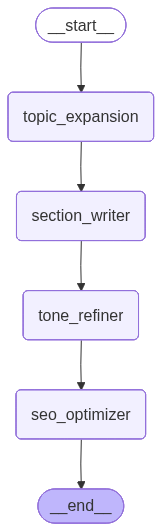

In [25]:
workflow


In [26]:
intial_state = {
    "raw_topic": "Is Degree relevent for job",
    "raw_tone" : "a 17 year boy"
}

fina_state = workflow.invoke(intial_state)


In [27]:
fina_state


{'raw_topic': 'Is Degree relevent for job',
 'raw_tone': 'a 17 year boy',
 'five_headline': ["Degree vs. Skills: Which Matters More in Today's Job Market?",
  'The Degree Debate: Is Higher Education Still the Golden Ticket to Employment?',
  'Beyond the Diploma: Why Practical Skills Trump a Degree for Career Success',
  'Job Ready: How to Land Your Dream Role Without a Four-Year Degree',
  'The Evolving Role of Degrees in a Skills-Based Economy'],
 'tcontent': "1. Degree vs. Skills: Which Matters More in Today's Job Market?\n2. The Degree Debate: Is Higher Education Still the Golden Ticket to Employment?\n3. Beyond the Diploma: Why Practical Skills Trump a Degree for Career Success\n4. Job Ready: How to Land Your Dream Role Without a Four-Year Degree\n5. The Evolving Role of Degrees in a Skills-Based Economy",
 'section_summary': 'Here\'s a 10-line detailed summary synthesizing the provided topics:\n\nThe contemporary job market is undergoing a seismic shift, questioning the supremacy 

In [28]:
fina_state['persona']


'Here\'s a refined persona tone for a 17-year-old boy, drawing inspiration from your provided themes, broken down by how he might express himself and what his core concerns are:\n\n**Core Persona Elements:**\n\n*   **Age:** 17 years old. This means he\'s likely a high school junior or senior, on the cusp of major life decisions.\n*   **Key Concerns:** Future job prospects, financial independence, avoiding "wasted" time/money, proving his worth, and potentially challenging traditional paths.\n*   **Language Style:** Informal, often uses slang (but not overly aggressive or complex), direct, opinionated, sometimes a bit cynical about established systems. He\'s probably exposed to a lot of online content and quick-hit information.\n\n---\n\n**Persona Tone Refinement - Incorporating Your Themes:**\n\n**Overall Tone:** **Pragmatic, Skeptical, Empowered, Future-Focused.**\n\nLet\'s break it down with examples of how he might *think* or *say* things related to your themes:\n\n**1. Degree vs. S